# 📊 Prédiction du défaut de paiement de cartes de crédit
## Notebook principal — Méthodologie CRISP-DM

**Dataset** : Default of Credit Card Clients (UCI, 30 000 observations)  
**Objectif** : Construire un modèle prédictif du défaut de paiement  
**Méthodologie** : CRISP-DM (Cross-Industry Standard Process for Data Mining)  
**Modèles comparés** : Régression Logistique, Random Forest, Gradient Boosting

---

### Sommaire
1. Installation et imports
2. Phase 2 — Compréhension des données (EDA)
3. Phase 3 — Préparation des données
4. Phase 4 — Modélisation
5. Phase 5 — Évaluation
6. Phase 6 — Préparation au déploiement
7. Synthèse finale


## 🔧 1. Installation et imports

### 1.1 Installation des bibliothèques (à exécuter une seule fois)

In [ ]:
# Décommenter et exécuter si les packages ne sont pas installés
# !pip install pandas numpy matplotlib seaborn scikit-learn xlrd openpyxl joblib --quiet

### 1.2 Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn : prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-learn : modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-learn : métriques
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Configuration esthétique
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Bibliothèques importées avec succès")

✓ Bibliothèques importées avec succès


---
## 🔍 2. Phase 2 — Compréhension des données (EDA)


### 2.1 Chargement du dataset

In [2]:
# Adapter le chemin selon votre arborescence
FILE_PATH = "../data/raw/default of credit card clients.xls"

# header=1 car la première ligne contient un titre, les noms de colonnes sont en ligne 2
df = pd.read_excel(FILE_PATH, header=1)

# Renommage pour cohérence
df = df.rename(columns={
    'default payment next month': 'DEFAULT',
    'PAY_0': 'PAY_1'  # Harmonisation de la numérotation
})

print(f"Dimensions du dataset : {df.shape}")
print(f"Nombre de lignes : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]}")
df.head()

Dimensions du dataset : (30000, 25)
Nombre de lignes : 30,000
Nombre de colonnes : 25


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 2.2 Structure et types de données

In [3]:
print("=== INFO GÉNÉRALE ===")
df.info()

print("\n=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== INFO GÉNÉRALE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_1      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  i

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### 2.3 Détection des valeurs manquantes

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct.round(2)
})

print("=== VALEURS MANQUANTES ===")
print(missing_df[missing_df['Valeurs manquantes'] > 0])
print(f"\nTotal valeurs manquantes : {missing.sum()}")

=== VALEURS MANQUANTES ===
Empty DataFrame
Columns: [Valeurs manquantes, Pourcentage (%)]
Index: []

Total valeurs manquantes : 0


### 2.4 Analyse de la variable cible

=== RÉPARTITION DE LA CIBLE ===
Non-défaut (0) : 23,364 (77.88%)
Défaut (1)     : 6,636 (22.12%)


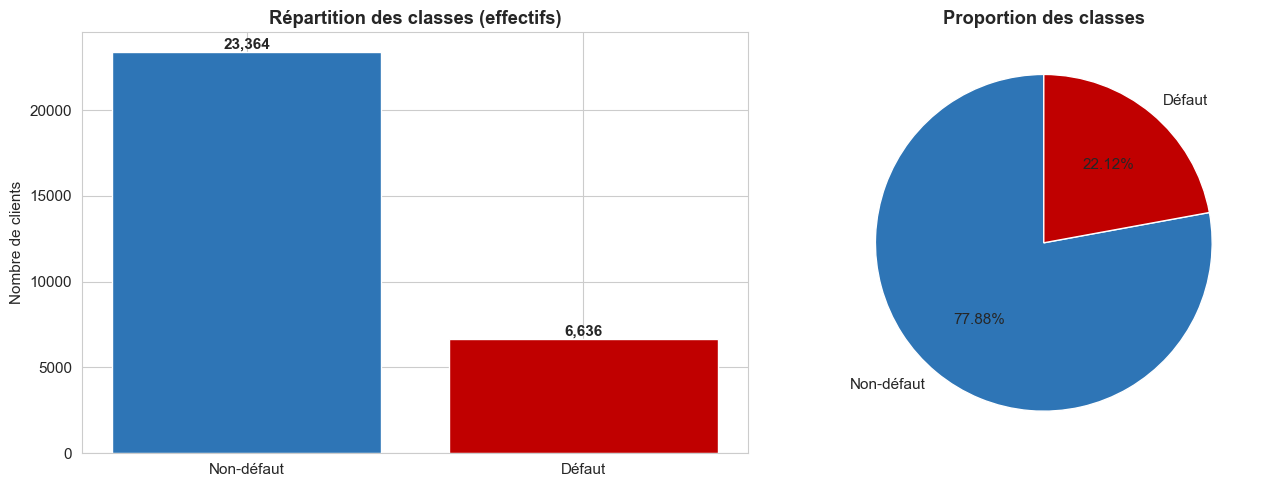

In [5]:
target_counts = df['DEFAULT'].value_counts()
target_pct = df['DEFAULT'].value_counts(normalize=True) * 100

print("=== RÉPARTITION DE LA CIBLE ===")
print(f"Non-défaut (0) : {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Défaut (1)     : {target_counts[1]:,} ({target_pct[1]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Non-défaut', 'Défaut'], target_counts.values,
            color=['#2E75B6', '#C00000'])
axes[0].set_title('Répartition des classes (effectifs)', fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['Non-défaut', 'Défaut'],
            autopct='%1.2f%%', colors=['#2E75B6', '#C00000'], startangle=90)
axes[1].set_title('Proportion des classes', fontweight='bold')

plt.tight_layout()
plt.show()

**Observation** : déséquilibre modéré ≈ 78% / 22%. Il faudra :
- Utiliser `class_weight='balanced'` lors de l'entraînement
- Privilégier le F1-score et l'AUC-ROC plutôt que l'accuracy seule
- Stratifier le split train/test

### 2.5 Variables catégorielles : détection des incohérences

In [6]:
print("=== SEX ===")
print(df['SEX'].value_counts().sort_index())
print("→ Dictionnaire attendu : 1=Homme, 2=Femme")

print("\n=== EDUCATION ===")
print(df['EDUCATION'].value_counts().sort_index())
print("→ Attendu : 1=Études sup, 2=Université, 3=Lycée, 4=Autres")
print("⚠️  Modalités 0, 5, 6 non documentées détectées")

print("\n=== MARRIAGE ===")
print(df['MARRIAGE'].value_counts().sort_index())
print("→ Attendu : 1=Marié, 2=Célibataire, 3=Autres")
print("⚠️  Modalité 0 non documentée détectée")

=== SEX ===
SEX
1    11888
2    18112
Name: count, dtype: int64
→ Dictionnaire attendu : 1=Homme, 2=Femme

=== EDUCATION ===
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
→ Attendu : 1=Études sup, 2=Université, 3=Lycée, 4=Autres
⚠️  Modalités 0, 5, 6 non documentées détectées

=== MARRIAGE ===
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64
→ Attendu : 1=Marié, 2=Célibataire, 3=Autres
⚠️  Modalité 0 non documentée détectée


### 2.6 Visualisations exploratoires

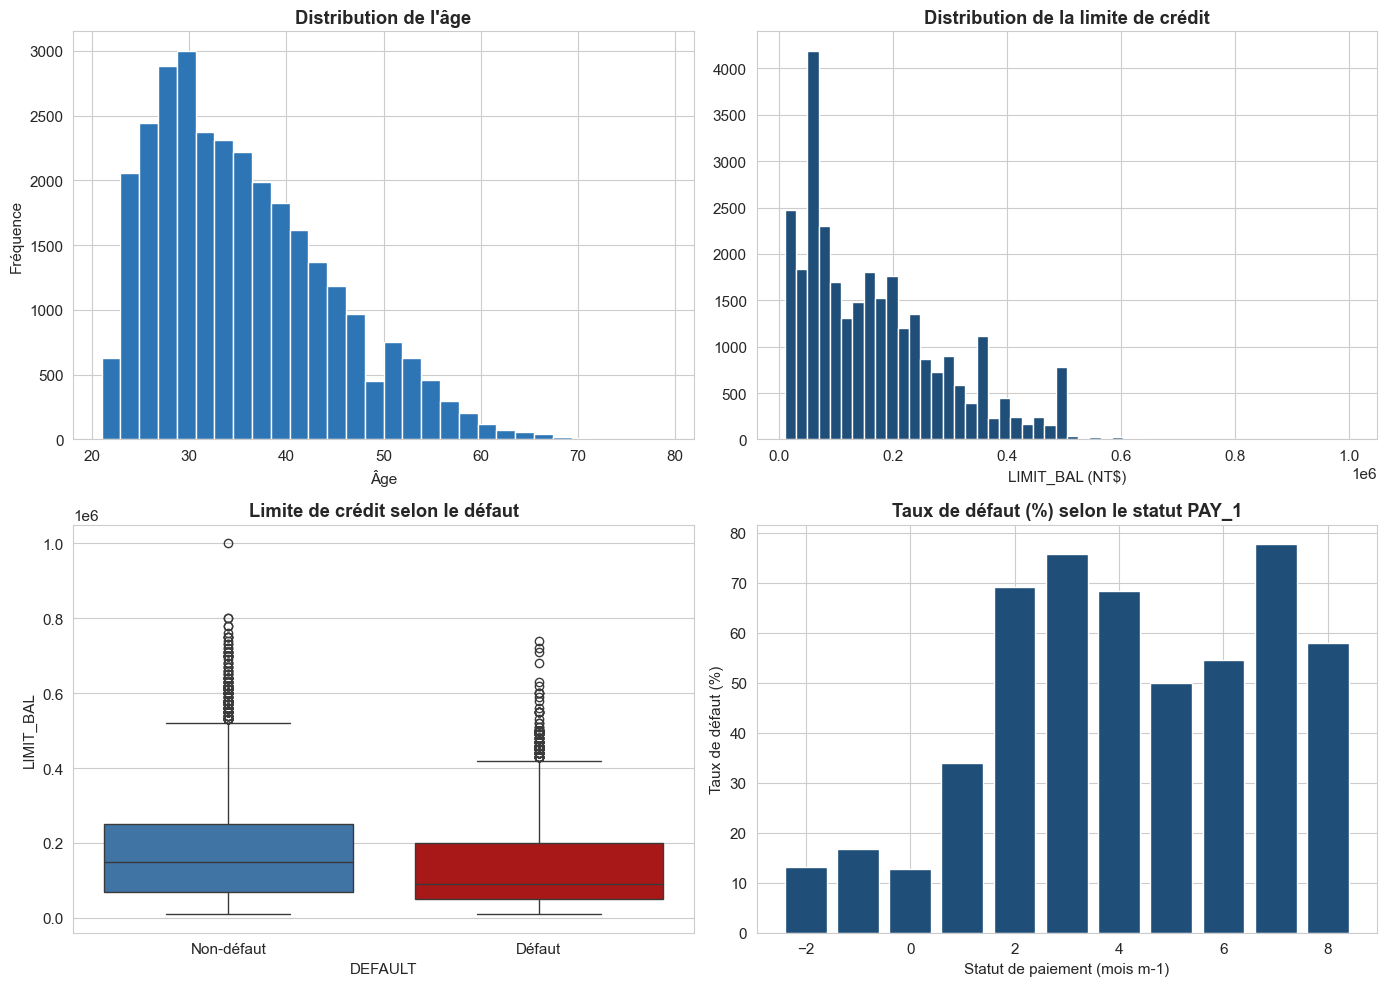

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution AGE
axes[0, 0].hist(df['AGE'], bins=30, color='#2E75B6', edgecolor='white')
axes[0, 0].set_title('Distribution de l\'âge', fontweight='bold')
axes[0, 0].set_xlabel('Âge')
axes[0, 0].set_ylabel('Fréquence')

# Distribution LIMIT_BAL
axes[0, 1].hist(df['LIMIT_BAL'], bins=50, color='#1F4E79', edgecolor='white')
axes[0, 1].set_title('Distribution de la limite de crédit', fontweight='bold')
axes[0, 1].set_xlabel('LIMIT_BAL (NT$)')

# LIMIT_BAL par classe
sns.boxplot(data=df, x='DEFAULT', y='LIMIT_BAL', ax=axes[1, 0],
            palette=['#2E75B6', '#C00000'])
axes[1, 0].set_title('Limite de crédit selon le défaut', fontweight='bold')
axes[1, 0].set_xticklabels(['Non-défaut', 'Défaut'])

# Taux de défaut par PAY_1
pay_default = df.groupby('PAY_1')['DEFAULT'].mean() * 100
axes[1, 1].bar(pay_default.index, pay_default.values, color='#1F4E79')
axes[1, 1].set_title('Taux de défaut (%) selon le statut PAY_1', fontweight='bold')
axes[1, 1].set_xlabel('Statut de paiement (mois m-1)')
axes[1, 1].set_ylabel('Taux de défaut (%)')

plt.tight_layout()
plt.show()

### 2.7 Matrice de corrélation

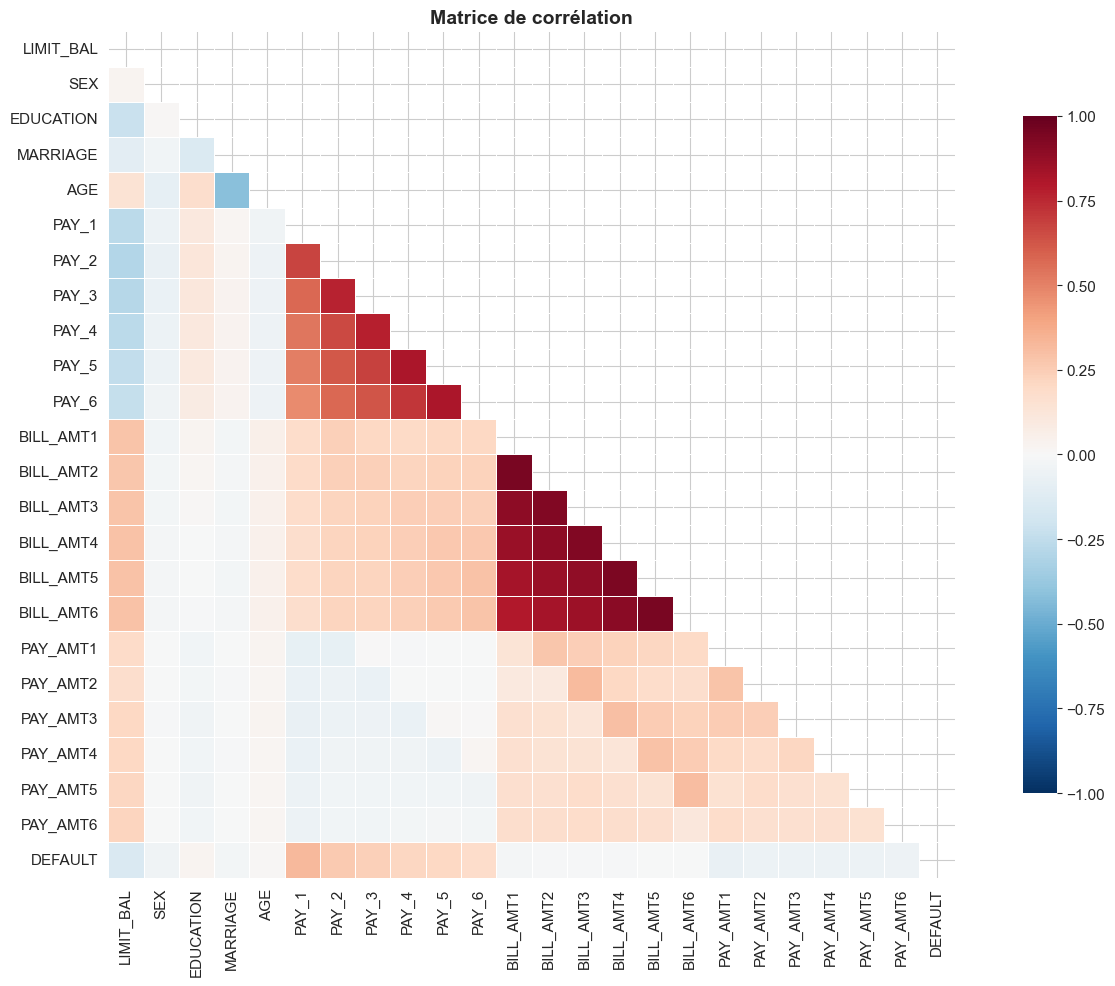

=== CORRÉLATIONS LES PLUS FORTES AVEC DEFAULT ===
PAY_1        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
Name: DEFAULT, dtype: float64


In [8]:
plt.figure(figsize=(14, 10))
corr_matrix = df.drop('ID', axis=1).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Top corrélations avec la cible
print("=== CORRÉLATIONS LES PLUS FORTES AVEC DEFAULT ===")
corr_target = corr_matrix['DEFAULT'].drop('DEFAULT').sort_values(key=abs, ascending=False)
print(corr_target.head(10))

**Observations clés** :
- Forte multicolinéarité entre BILL_AMT1 à BILL_AMT6 (à anticiper)
- PAY_1 est la variable la plus corrélée avec le défaut
- Les variables PAY_X sont fortement corrélées entre elles

---
## 🧹 3. Phase 3 — Préparation des données


### 3.1 Nettoyage des modalités incohérentes

In [9]:
# Copie pour préserver l'original
df_clean = df.copy()

# EDUCATION : 0, 5, 6 → 4 (Autres)
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE : 0 → 3 (Autres)
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})

print("=== APRÈS NETTOYAGE ===")
print("\nEDUCATION :")
print(df_clean['EDUCATION'].value_counts().sort_index())
print("\nMARRIAGE :")
print(df_clean['MARRIAGE'].value_counts().sort_index())

=== APRÈS NETTOYAGE ===

EDUCATION :
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE :
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


### 3.2 Séparation features (X) / cible (y)

In [10]:
X = df_clean.drop(['ID', 'DEFAULT'], axis=1)
y = df_clean['DEFAULT']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nVariables explicatives :\n{X.columns.tolist()}")

X shape : (30000, 23)
y shape : (30000,)

Variables explicatives :
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


### 3.3 Encodage One-Hot

In [11]:
# drop_first=True évite la "dummy variable trap" (colinéarité parfaite)
X_encoded = pd.get_dummies(
    X,
    columns=['SEX', 'EDUCATION', 'MARRIAGE'],
    drop_first=True,
    dtype=int
)

print(f"Avant encodage : {X.shape}")
print(f"Après encodage : {X_encoded.shape}")
print(f"\nColonnes créées : {[c for c in X_encoded.columns if c not in X.columns]}")

Avant encodage : (30000, 23)
Après encodage : (30000, 26)

Colonnes créées : ['SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


### 3.4 Split train/test stratifié

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y           # CRUCIAL : conserve la proportion de défauts
)

print(f"X_train : {X_train.shape}  →  {len(X_train):,} observations")
print(f"X_test  : {X_test.shape}  →  {len(X_test):,} observations")
print(f"\nTaux de défaut train : {y_train.mean()*100:.2f}%")
print(f"Taux de défaut test  : {y_test.mean()*100:.2f}%")

X_train : (24000, 26)  →  24,000 observations
X_test  : (6000, 26)  →  6,000 observations

Taux de défaut train : 22.12%
Taux de défaut test  : 22.12%


### 3.5 Standardisation (pour la régression logistique)

In [13]:
# fit_transform sur train, transform seulement sur test (évite la fuite de données)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Moyenne X_train_scaled (≈ 0) : {X_train_scaled.mean():.4f}")
print(f"Écart-type X_train_scaled (≈ 1) : {X_train_scaled.std():.4f}")

Moyenne X_train_scaled (≈ 0) : 0.0000
Écart-type X_train_scaled (≈ 1) : 1.0000


---
## 🤖 4. Phase 4 — Modélisation


### 4.1 Modèle 1 — Régression Logistique

In [14]:
print("="*60)
print("MODÈLE 1 — RÉGRESSION LOGISTIQUE")
print("="*60)

model_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)
y_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

print("✓ Modèle entraîné")
print(f"Intercept : {model_lr.intercept_[0]:.4f}")
print(f"Nombre de coefficients : {len(model_lr.coef_[0])}")

MODÈLE 1 — RÉGRESSION LOGISTIQUE
✓ Modèle entraîné
Intercept : -0.2001
Nombre de coefficients : 26


### 4.2 Modèle 2 — Random Forest

In [15]:
print("="*60)
print("MODÈLE 2 — RANDOM FOREST")
print("="*60)

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("✓ Modèle entraîné")
print(f"Nombre d'arbres : {model_rf.n_estimators}")
print(f"Profondeur max : {model_rf.max_depth}")

MODÈLE 2 — RANDOM FOREST
✓ Modèle entraîné
Nombre d'arbres : 200
Profondeur max : 10


### 4.3 Modèle 3 — Gradient Boosting

In [16]:
print("="*60)
print("MODÈLE 3 — GRADIENT BOOSTING")
print("="*60)

model_gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)
model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)
y_proba_gb = model_gb.predict_proba(X_test)[:, 1]

print("✓ Modèle entraîné")
print(f"Estimateurs : {model_gb.n_estimators}")
print(f"Profondeur : {model_gb.max_depth}")
print(f"Learning rate : {model_gb.learning_rate}")

MODÈLE 3 — GRADIENT BOOSTING
✓ Modèle entraîné
Estimateurs : 200
Profondeur : 4
Learning rate : 0.1


---
## 📊 5. Phase 5 — Évaluation


### 5.1 Fonction utilitaire d'évaluation

In [17]:
def evaluer_modele(nom, y_true, y_pred, y_proba):
    """Calcule les métriques principales."""
    return {
        'Modèle': nom,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Précision': precision_score(y_true, y_pred),
        'Sensibilité': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_proba)
    }

results = [
    evaluer_modele('Régression Logistique', y_test, y_pred_lr, y_proba_lr),
    evaluer_modele('Random Forest',         y_test, y_pred_rf, y_proba_rf),
    evaluer_modele('Gradient Boosting',     y_test, y_pred_gb, y_proba_gb)
]

df_results = pd.DataFrame(results)
df_results_display = df_results.copy()
for col in ['Accuracy', 'Précision', 'Sensibilité', 'F1-Score', 'AUC-ROC']:
    df_results_display[col] = df_results_display[col].apply(lambda x: f"{x:.4f}")

print("="*70)
print("TABLEAU COMPARATIF DES MÉTRIQUES")
print("="*70)
print(df_results_display.to_string(index=False))

TABLEAU COMPARATIF DES MÉTRIQUES
               Modèle Accuracy Précision Sensibilité F1-Score AUC-ROC
Régression Logistique   0.6785    0.3678      0.6307   0.4646  0.7104
        Random Forest   0.7903    0.5244      0.5584   0.5409  0.7722
    Gradient Boosting   0.8150    0.6460      0.3617   0.4638  0.7770


### 5.2 Matrices de confusion comparées

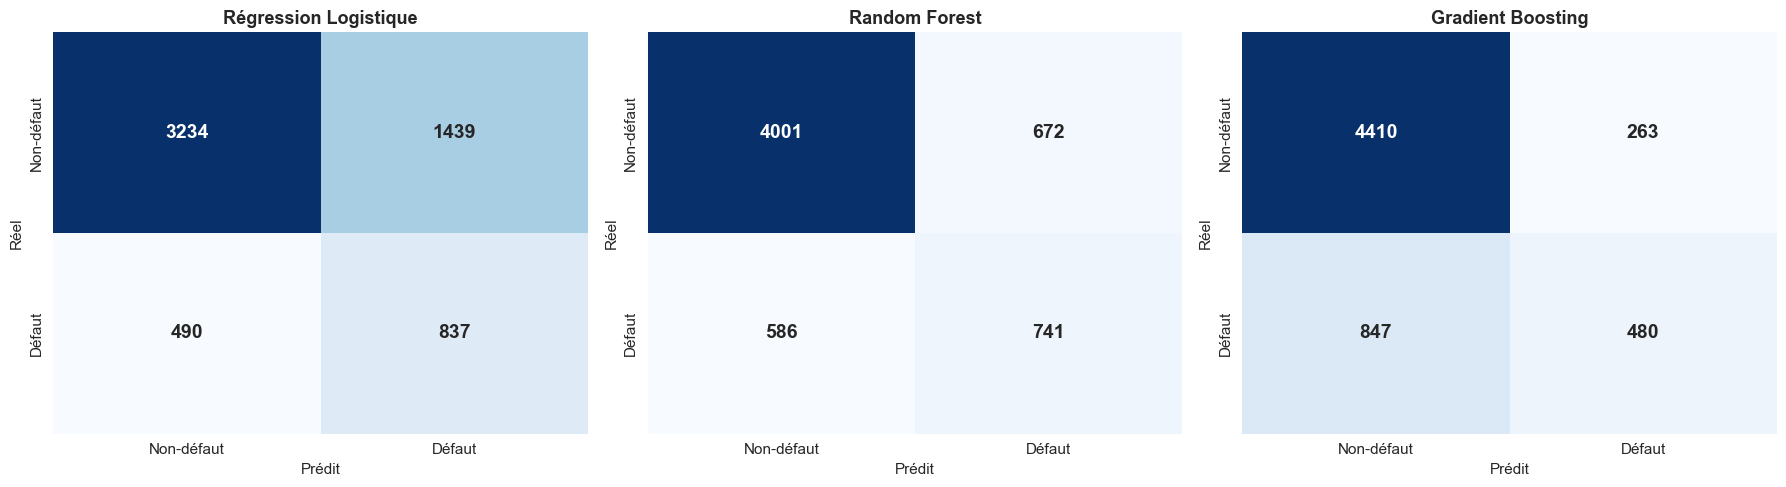

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_data = [
    ('Régression Logistique', y_pred_lr),
    ('Random Forest',         y_pred_rf),
    ('Gradient Boosting',     y_pred_gb)
]

for ax, (nom, y_pred) in zip(axes, models_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-défaut', 'Défaut'],
                yticklabels=['Non-défaut', 'Défaut'],
                cbar=False, annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(nom, fontweight='bold', fontsize=13)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()

### 5.3 Courbes ROC

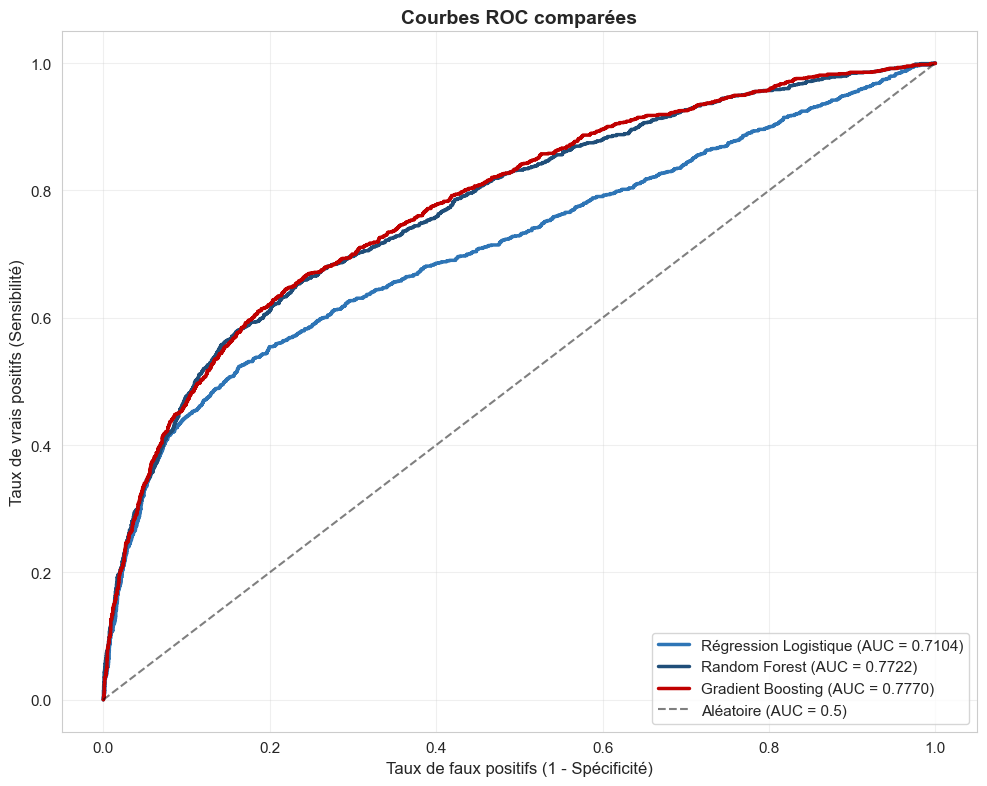

In [19]:
plt.figure(figsize=(10, 8))

for nom, y_proba, couleur in [
    ('Régression Logistique', y_proba_lr, '#2E75B6'),
    ('Random Forest',         y_proba_rf, '#1F4E79'),
    ('Gradient Boosting',     y_proba_gb, '#C00000')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nom} (AUC = {auc:.4f})',
             linewidth=2.5, color=couleur)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de faux positifs (1 - Spécificité)', fontsize=12)
plt.ylabel('Taux de vrais positifs (Sensibilité)', fontsize=12)
plt.title('Courbes ROC comparées', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Importance des variables (Random Forest — modèle retenu)

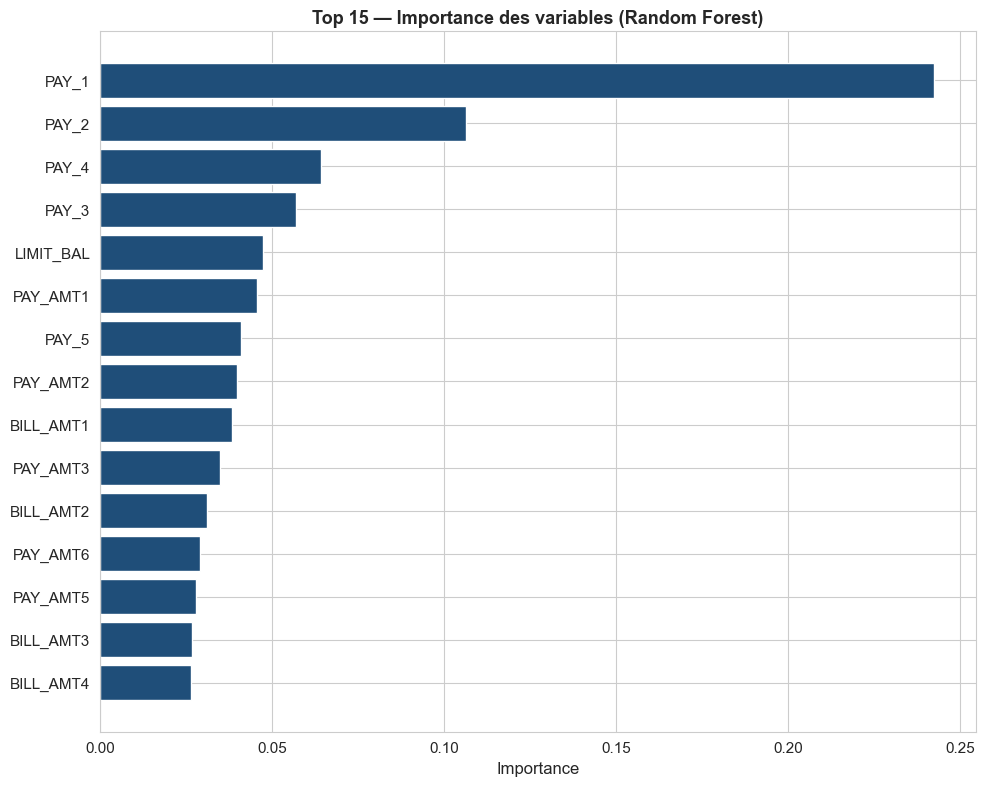


=== TOP 10 ===
 Variable  Importance
    PAY_1    0.242449
    PAY_2    0.106483
    PAY_4    0.064195
    PAY_3    0.056855
LIMIT_BAL    0.047363
 PAY_AMT1    0.045774
    PAY_5    0.040907
 PAY_AMT2    0.039799
BILL_AMT1    0.038446
 PAY_AMT3    0.034797


In [20]:
feature_importance = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

top15 = feature_importance.head(15)

plt.figure(figsize=(10, 8))
plt.barh(top15['Variable'][::-1], top15['Importance'][::-1], color='#1F4E79')
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 — Importance des variables (Random Forest)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== TOP 10 ===")
print(top15.head(10).to_string(index=False))

### 5.5 Rapports de classification détaillés

In [21]:
for nom, y_pred in models_data:
    print("="*60)
    print(f"  {nom}")
    print("="*60)
    print(classification_report(y_test, y_pred,
                                target_names=['Non-défaut', 'Défaut'],
                                digits=4))

  Régression Logistique
              precision    recall  f1-score   support

  Non-défaut     0.8684    0.6921    0.7703      4673
      Défaut     0.3678    0.6307    0.4646      1327

    accuracy                         0.6785      6000
   macro avg     0.6181    0.6614    0.6174      6000
weighted avg     0.7577    0.6785    0.7027      6000

  Random Forest
              precision    recall  f1-score   support

  Non-défaut     0.8722    0.8562    0.8641      4673
      Défaut     0.5244    0.5584    0.5409      1327

    accuracy                         0.7903      6000
   macro avg     0.6983    0.7073    0.7025      6000
weighted avg     0.7953    0.7903    0.7927      6000

  Gradient Boosting
              precision    recall  f1-score   support

  Non-défaut     0.8389    0.9437    0.8882      4673
      Défaut     0.6460    0.3617    0.4638      1327

    accuracy                         0.8150      6000
   macro avg     0.7425    0.6527    0.6760      6000
weighted avg  

---
## 🚀 6. Phase 6 — Préparation au déploiement


### 6.1 Sauvegarde du modèle retenu

In [22]:
import joblib

# Sauvegardes essentielles pour la mise en production
joblib.dump(model_rf, 'model_random_forest_final.pkl')
joblib.dump(list(X_train.columns), 'feature_names.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✓ Modèle sauvegardé : model_random_forest_final.pkl")
print("✓ Liste des features sauvegardée : feature_names.pkl")
print("✓ Scaler sauvegardé : scaler.pkl")

✓ Modèle sauvegardé : model_random_forest_final.pkl
✓ Liste des features sauvegardée : feature_names.pkl
✓ Scaler sauvegardé : scaler.pkl


### 6.2 Fonction de scoring pour production

In [23]:
def predire_defaut(client_data, model=model_rf, feature_names=list(X_train.columns)):
    """
    Prédit la probabilité de défaut pour un nouveau client.

    Paramètres
    ----------
    client_data : dict
        Dictionnaire des features (mêmes noms que X_train).
    model : modèle entraîné
    feature_names : liste des noms de colonnes attendus

    Retour
    ------
    dict avec probabilité et décision
    """
    df_client = pd.DataFrame([client_data])[feature_names]
    proba_defaut = model.predict_proba(df_client)[0, 1]
    prediction = int(proba_defaut >= 0.5)

    return {
        'probabilite_defaut': round(proba_defaut, 4),
        'prediction': prediction,
        'decision': 'À RISQUE' if prediction == 1 else 'ACCEPTABLE',
        'niveau_risque': (
            'Très élevé' if proba_defaut >= 0.7 else
            'Élevé'      if proba_defaut >= 0.5 else
            'Modéré'     if proba_defaut >= 0.3 else
            'Faible'
        )
    }


# Exemple : premier client du test set
exemple_client = X_test.iloc[0].to_dict()
resultat = predire_defaut(exemple_client)

print("=== SCORING D'UN CLIENT ===")
for k, v in resultat.items():
    print(f"{k:25s} : {v}")
print(f"\n(Valeur réelle pour cet exemple : {y_test.iloc[0]})")

=== SCORING D'UN CLIENT ===
probabilite_defaut        : 0.3026
prediction                : 0
decision                  : ACCEPTABLE
niveau_risque             : Modéré

(Valeur réelle pour cet exemple : 0)


---
## 📝 7. Synthèse finale


In [24]:
print("="*70)
print("  SYNTHÈSE — PRÉDICTION DU DÉFAUT DE PAIEMENT")
print("="*70)

print(f"\n📊 Dataset : {df.shape[0]:,} observations × {df.shape[1]} variables")
print(f"🎯 Taux de défaut : {y.mean()*100:.2f}%")
print(f"📂 Split train/test : {len(X_train):,} / {len(X_test):,}\n")

print(df_results_display.to_string(index=False))

print(f"\n🏆 MODÈLE RETENU : Random Forest")
print(f"   • F1-Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"   • AUC-ROC  : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"   • Variable dominante : PAY_1 ({feature_importance.iloc[0]['Importance']*100:.1f}%)")

print("\n✅ Projet terminé")
print("\n👉 Pour aller plus loin, ouvrez le notebook 'Notebook_Ameliorations.ipynb'")

  SYNTHÈSE — PRÉDICTION DU DÉFAUT DE PAIEMENT

📊 Dataset : 30,000 observations × 25 variables
🎯 Taux de défaut : 22.12%
📂 Split train/test : 24,000 / 6,000

               Modèle Accuracy Précision Sensibilité F1-Score AUC-ROC
Régression Logistique   0.6785    0.3678      0.6307   0.4646  0.7104
        Random Forest   0.7903    0.5244      0.5584   0.5409  0.7722
    Gradient Boosting   0.8150    0.6460      0.3617   0.4638  0.7770

🏆 MODÈLE RETENU : Random Forest
   • F1-Score : 0.5409
   • AUC-ROC  : 0.7722
   • Variable dominante : PAY_1 (24.2%)

✅ Projet terminé

👉 Pour aller plus loin, ouvrez le notebook 'Notebook_Ameliorations.ipynb'


---
## 📚 Bonnes pratiques appliquées dans ce notebook

| Pratique | Détail |
|---|---|
| Reproductibilité | `random_state=42` fixé partout |
| Stratification | `stratify=y` dans le split train/test |
| Anti-leakage | `fit_transform` train, `transform` test |
| Anti-overfitting | `max_depth` limité, régularisation L2 |
| Multicolinéarité | `drop_first=True` dans le one-hot encoding |
| Déséquilibre | `class_weight='balanced'` |
| DRY | Fonction `evaluer_modele()` réutilisable |
| Métriques adaptées | F1 + AUC, pas seulement accuracy |

---
*Notebook réalisé dans le cadre du programme AEC Business Analyse & Data Analytics.*
